# Template notebook

You’re working with **Northstar Desk**, a UK-based subscription software company. Over the last year, the team has handled a steady stream of operational cases: billing and renewals, access and admin requests, reporting issues, integrations, bugs, and occasional performance incidents. The dataset you’ve been given is a snapshot export from Northstar’s case management system: each row is one case, with structured triage fields, outcomes, timings, and a short free-text summary.

Northstar doesn’t want a “fully automated AI that replaces support staff”. They want something more practical: a tool that helps humans **make better decisions, faster**, using the data they already have.

## Your mission

Build a **decision-support prototype** that improves how a frontline or operational user handles cases. Your tool can focus on any part of the workflow, as long as it produces something a real person could use.

Your prototype should support at least one of these outcomes:

- **Understand** what’s coming in (themes, clusters, common issues, emerging patterns)  
- **Prioritise** what to look at first (risk signals, urgency proxies, workload triage)  
- **Route** work more effectively (suggest team/category/subcategory, detect likely escalations)  
- **Resolve** issues faster (surface likely next steps, similar cases, common fixes)  
- **Learn** from outcomes (what tends to lead to long resolution times, escalations, poor CSAT)

You can interpret “decision-support” broadly. The key is that it helps a user do something concrete with the case data.

## Prototype requirement (this is the steer)

Your prototype must be an **interactive tool**, not just analysis:

- A **Gradio app** (recommended), or other small deployable interface.  
- It can be simple: one or two screens, a small number of inputs, and clear outputs.  
- It should demonstrate a realistic workflow: a user provides inputs (e.g. a case summary, category, priority, or a date range) and your tool returns helpful outputs (e.g. routing suggestions, similar cases, risk flags, or a summary of patterns).

A notebook is fine for development, but the end result should include an interface that could plausibly be shared with a non-technical colleague.

## Choose a track (optional)

If you’re having trouble choosing what to build, you can try one of the following tracks:

- **Track 1: Triage assistant** — classify, route, prioritise, or flag risk for new cases.  
- **Track 2: Ops insight tool** — explore trends and spikes, with filters a team lead would use.  
- **Track 3: Similarity + retrieval tool** — find related cases and surface “what worked before”.  
- **Track 4: Process quality tool** — analyse what drives delays/escalations and where process breaks down (optional fairness checks as audit, not decisioning).

Any track is valid. You’re judged on usefulness and clarity, not on picking the “right” one.

## What you’ll present (end of day 2)

1. **Working prototype**  
    Gradio app (or similar) demonstrating the decision-support workflow.  
2. **Short technical summary**  
    Data prep, modelling choices, and why they make sense. Risks, limitations, and interpretability choices.  
3. **Short user-facing story**  
    Who uses the tool, what problem it solves for them, and how they’d use it day-to-day.  
4. **Roadmap**  
    What you’d do next with another week, or if you were building this internally (data, modelling, UX, governance, monitoring).


## Libraries
As always, we'll start by importing the necessary libraries.

In [3]:
# It's good practice to add comments to explain your code 
import numpy as np
import pandas as pd

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from data_loader import add_derived_fields, load_cases

cases = add_derived_fields(load_cases())
print(f"Cases: {len(cases):,}")
print(f"Date range: {cases['created_at'].min()} -> {cases['created_at'].max()}")
cases.head()

Cases: 1,730
Date range: 2025-01-02 09:15:22+00:00 -> 2025-12-30 16:10:22+00:00


,case_id,snapshot_at,created_at,channel,case_type,category,subcategory,priority,sla_target_hours,first_response_time_hours,...,gender,case_summary,sentiment,csat_score,tags,source_file,sla_breach,slow_resolution,low_csat,search_text
0,ND-2025-000001,2026-01-01 00:00:00+00:00,2025-01-02 09:15:22+00:00,email,service_request,how_to_training,onboarding_help,Medium,24.0,2.5,...,F,How do I add a new Polaris Board for the marke...,Neutral,5.0,how_to; onboarding; polaris; configuration,Q1-Jan.csv,False,True,False,How do I add a new Polaris Board for the marke...
1,ND-2025-000002,2026-01-01 00:00:00+00:00,2025-01-02 10:04:11+00:00,webchat,service_request,how_to_training,feature_how_to,Low,48.0,5.1,...,M,Need help setting up widgets on my dashboard,Neutral,4.0,how_to; widget; dashboard; setup,Q1-Jan.csv,False,True,False,Need help setting up widgets on my dashboard h...
2,ND-2025-000003,2026-01-01 00:00:00+00:00,2025-01-02 11:22:45+00:00,in_app,incident,access_permissions,password_reset,High,8.0,0.5,...,M,Orbit ID isn't accepting my password after the...,Negative,4.0,orbit_id; password; login; locked_out,Q1-Jan.csv,False,False,False,Orbit ID isn't accepting my password after the...
3,ND-2025-000004,2026-01-01 00:00:00+00:00,2025-01-03 08:45:00+00:00,email,service_request,how_to_training,best_practice,Low,48.0,12.2,...,F,What's the best practice for sharing Polaris B...,Neutral,NaN,how_to; best_practice; polaris; sharing,Q1-Jan.csv,False,False,False,What's the best practice for sharing Polaris B...
4,ND-2025-000005,2026-01-01 00:00:00+00:00,2025-01-03 09:10:15+00:00,phone,incident,billing_payments,invoice_error,Urgent,4.0,0.2,...,M,Double charged for the Pro tier upgrade on my ...,Negative,3.0,invoice; duplicate_charge; pro_tier; billing,Q1-Jan.csv,False,False,False,Double charged for the Pro tier upgrade on my ...


In [5]:
summary = pd.DataFrame(
    {
        "metric": [
            "Escalation rate",
            "Open / pending rate",
            "Median resolution (hours)",
            "Low CSAT rate (<=2)",
        ],
        "value": [
            f"{cases['escalated'].mean():.1%}",
            f"{cases['status'].isin(['open', 'pending', 'new', 'on_hold']).mean():.1%}",
            f"{cases['resolution_time_hours'].median():.1f}",
            f"{cases['low_csat'].mean():.1%}",
        ],
    }
)
summary

,metric,value
0,Escalation rate,13.3%
1,Open / pending rate,28.4%
2,Median resolution (hours),11.5
3,Low CSAT rate (<=2),8.7%


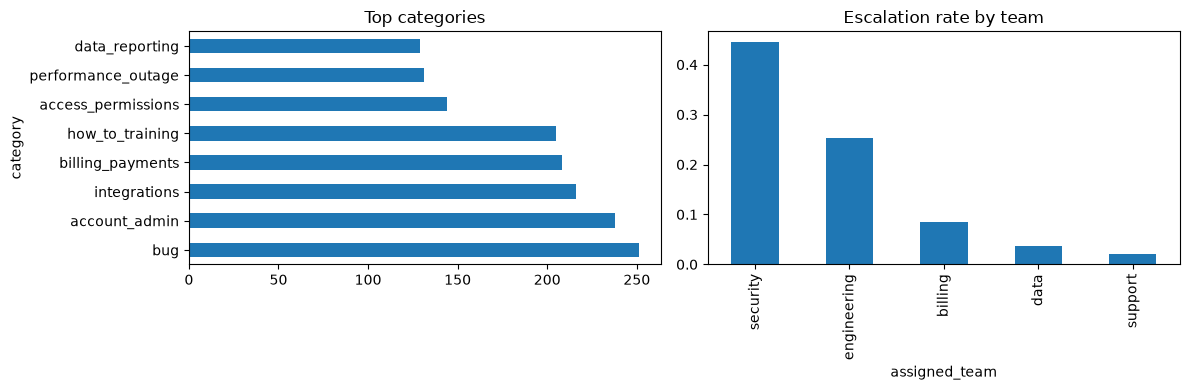

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cases["category"].value_counts().head(8).plot(kind="barh", ax=axes[0], title="Top categories")
cases.groupby("assigned_team")["escalated"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], title="Escalation rate by team"
)
plt.tight_layout()

In [7]:
from triage_engine import TriageEngine, format_similar_cases, format_suggestion

engine = TriageEngine(cases)
sample = engine.suggest(
    "CSV export is blank for the sales report and finance need it today.",
    channel="email",
    plan_tier="Enterprise",
)
print(format_suggestion(sample))
print("\n")
print(format_similar_cases(sample.similar_cases))

## Routing suggestion
- **Team:** support (50% confidence)
- **Category:** data_reporting (25% confidence)
- **Priority:** Medium (38% confidence)

## Risk signals
- **Escalation risk:** 35%
- **Flags:** blank


### ND-2025-001125 (similarity 50%)
**Summary:** CSV export is blank
**Route:** data · data_reporting/csv · Medium
**Outcome:** open · n/a · escalated=False · CSAT n/a

### ND-2025-002008 (similarity 50%)
**Summary:** CSV export is coming out blank for the sales report.
**Route:** support · bug/export_bug · High
**Outcome:** open · n/a · escalated=True · CSAT n/a

### ND-2025-001082 (similarity 33%)
**Summary:** CSV export is formatting dates weirdly
**Route:** engineering · bug/export_bug · Medium
**Outcome:** new · n/a · escalated=False · CSAT n/a


## Model evaluation

Cross-validation on **case summary only** — matches what the Gradio app receives at inference time (not enriched category/tags).

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

train = cases[cases["case_summary"].str.len() > 0].copy()
X = train["case_summary"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_classifier(y, scoring="accuracy"):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring)
    return scores.mean(), scores.std()


results = []
for target in ["assigned_team", "category", "priority"]:
    mean, std = evaluate_classifier(train[target])
    results.append({"target": target, "metric": "accuracy", "mean": mean, "std": std})

esc_mean, esc_std = evaluate_classifier(train["escalated"].astype(int), scoring="roc_auc")
results.append({"target": "escalated", "metric": "roc_auc", "mean": esc_mean, "std": esc_std})

eval_df = pd.DataFrame(results)
eval_df["score"] = eval_df.apply(lambda r: f"{r['mean']:.1%} ± {r['std']:.1%}", axis=1)
print("5-fold cross-validation (case_summary only — matches app input)")
eval_df[["target", "metric", "score"]]

5-fold cross-validation (case_summary only — matches app input)


,target,metric,score
0,assigned_team,accuracy,83.2% ± 2.3%
1,category,accuracy,85.5% ± 1.5%
2,priority,accuracy,60.7% ± 1.8%
3,escalated,roc_auc,87.5% ± 1.4%


Cases with confidence < 50% (agent should treat as weak hint):
  assigned_team: 14.5%
  category: 34.2%
  priority: 30.8%


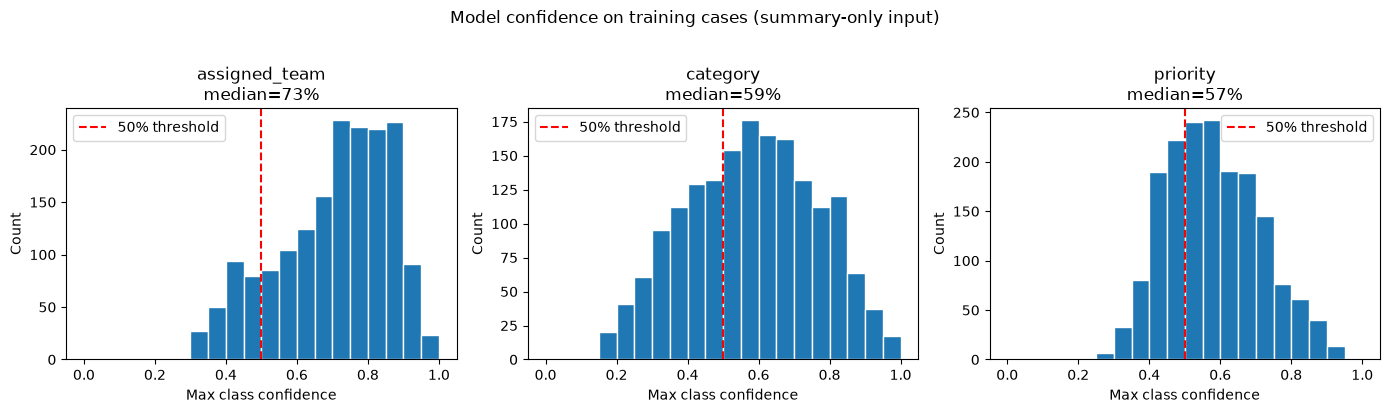

In [9]:
targets = {
    "assigned_team": train["assigned_team"],
    "category": train["category"],
    "priority": train["priority"],
}

confidence_rows = []
for target_name, y in targets.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1000)),
    ])
    pipe.fit(X, y)
    proba = pipe.predict_proba(X).max(axis=1)
    for conf in proba:
        confidence_rows.append({"target": target_name, "confidence": conf})

conf_df = pd.DataFrame(confidence_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, target in zip(axes, targets.keys()):
    subset = conf_df[conf_df["target"] == target]["confidence"]
    ax.hist(subset, bins=20, range=(0, 1), edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", label="50% threshold")
    ax.set_title(f"{target}\nmedian={subset.median():.0%}")
    ax.set_xlabel("Max class confidence")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Model confidence on training cases (summary-only input)", y=1.02)
plt.tight_layout()

print("Cases with confidence < 50% (agent should treat as weak hint):")
for target in targets:
    subset = conf_df[conf_df["target"] == target]["confidence"]
    print(f"  {target}: {(subset < 0.5).mean():.1%}")